In [1]:
import pandas as pd

product_features = pd.read_csv(
    "../data/processed/product_features.csv",
    index_col=0
)

product_features.head()

,order_frequency,total_quantity,avg_quantity_per_order,related_product_count
StockCode,,,,
10002,71,860,12.112676,2067
10080,22,303,13.772727,908
10120,29,192,6.620690,1001
10123C,3,5,1.666667,85
10124A,5,16,3.200000,196


In [2]:
features = [
    "order_frequency",
    "total_quantity",
    "avg_quantity_per_order",
    "related_product_count"
]

X = product_features[features]

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertia.append(model.inertia_)

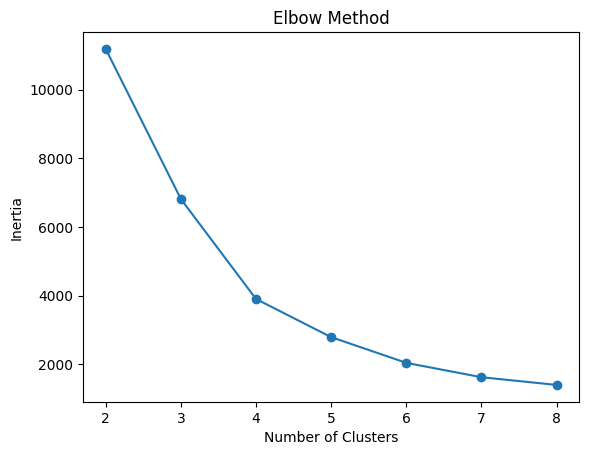

In [5]:
plt.plot(range(2, 9), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
product_features["cluster"].value_counts().sort_index()

cluster
0    2192
1    1551
2       1
3     178
Name: count, dtype: int64

In [8]:
cluster_summary = product_features.groupby("cluster")[features].mean()

cluster_summary

,order_frequency,total_quantity,avg_quantity_per_order,related_product_count
cluster,,,,
0,161.242245,1414.904653,8.332226,2573.554288
1,17.390071,173.529336,8.311271,827.516441
2,1.000000,80995.000000,80995.000000,0.000000
3,781.949438,11914.662921,18.124522,3237.657303


In [9]:
cluster_names = {
    0: "Active Products",
    1: "Slow-Moving Products",
    2: "Bulk/Outlier Product",
    3: "High-Priority Products"
}

In [10]:
product_features["cluster_name"] = product_features["cluster"].map(cluster_names)

In [11]:
product_features[
    ["cluster", "cluster_name"]
].head(20)

,cluster,cluster_name
StockCode,,
10002,0,Active Products
10080,1,Slow-Moving Products
10120,1,Slow-Moving Products
10123C,1,Slow-Moving Products
10124A,1,Slow-Moving Products
10124G,1,Slow-Moving Products
10125,0,Active Products
10133,0,Active Products
10135,0,Active Products


In [12]:
product_features.head()

,order_frequency,total_quantity,avg_quantity_per_order,related_product_count,cluster,cluster_name
StockCode,,,,,,
10002,71,860,12.112676,2067,0,Active Products
10080,22,303,13.772727,908,1,Slow-Moving Products
10120,29,192,6.620690,1001,1,Slow-Moving Products
10123C,3,5,1.666667,85,1,Slow-Moving Products
10124A,5,16,3.200000,196,1,Slow-Moving Products


In [13]:
product_features.head(30)

,order_frequency,total_quantity,avg_quantity_per_order,related_product_count,cluster,cluster_name
StockCode,,,,,,
10002,71,860,12.112676,2067,0,Active Products
10080,22,303,13.772727,908,1,Slow-Moving Products
10120,29,192,6.620690,1001,1,Slow-Moving Products
10123C,3,5,1.666667,85,1,Slow-Moving Products
10124A,5,16,3.200000,196,1,Slow-Moving Products
10124G,4,17,4.250000,199,1,Slow-Moving Products
10125,91,1295,14.230769,2373,0,Active Products
10133,196,2856,14.571429,2732,0,Active Products
10135,175,2229,12.737143,2893,0,Active Products


In [14]:
product_features["cluster_name"].value_counts()

cluster_name
Active Products           2192
Slow-Moving Products      1551
High-Priority Products     178
Bulk/Outlier Product         1
Name: count, dtype: int64

In [15]:
product_features.to_csv(
    "../data/processed/product_clusters.csv",
    index=False
)